1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

2. Load & Explore the Dataset

In [4]:
# Load dataset 
df = pd.read_csv("C:\\Users\\Dhanush\\Downloads\\Dataset.csv")

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset Shape: (25000, 24)

Column names:
['Ware_house_ID', 'WH_Manager_ID', 'Location_type', 'WH_capacity_size', 'zone', 'WH_regional_zone', 'num_refill_req_l3m', 'transport_issue_l1y', 'Competitor_in_mkt', 'retail_shop_num', 'wh_owner_type', 'distributor_num', 'flood_impacted', 'flood_proof', 'electric_supply', 'dist_from_hub', 'workers_num', 'wh_est_year', 'storage_issue_reported_l3m', 'temp_reg_mach', 'approved_wh_govt_certificate', 'wh_breakdown_l3m', 'govt_check_l3m', 'product_wg_ton']


In [5]:
df.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 25000 non-null  object 
 1   WH_Manager_ID                 25000 non-null  object 
 2   Location_type                 25000 non-null  object 
 3   WH_capacity_size              25000 non-null  object 
 4   zone                          25000 non-null  object 
 5   WH_regional_zone              25000 non-null  object 
 6   num_refill_req_l3m            25000 non-null  int64  
 7   transport_issue_l1y           25000 non-null  int64  
 8   Competitor_in_mkt             25000 non-null  int64  
 9   retail_shop_num               25000 non-null  int64  
 10  wh_owner_type                 25000 non-null  object 
 11  distributor_num               25000 non-null  int64  
 12  flood_impacted                25000 non-null  int64  
 13  f

In [7]:
df.describe()

,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,24010.000000,13119.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.089040,0.773680,3.104200,4985.711560,42.418120,0.098160,0.054640,0.656880,163.537320,28.944398,2009.383185,17.130440,0.303280,3.482040,18.812280,22102.632920
std,2.606612,1.199449,1.141663,1052.825252,16.064329,0.297537,0.227281,0.474761,62.718609,7.872534,7.528230,9.161108,0.459684,1.690335,8.632382,11607.755077
min,0.000000,0.000000,0.000000,1821.000000,15.000000,0.000000,0.000000,0.000000,55.000000,10.000000,1996.000000,0.000000,0.000000,0.000000,1.000000,2065.000000
25%,2.000000,0.000000,2.000000,4313.000000,29.000000,0.000000,0.000000,0.000000,109.000000,24.000000,2003.000000,10.000000,0.000000,2.000000,11.000000,13059.000000
50%,4.000000,0.000000,3.000000,4859.000000,42.000000,0.000000,0.000000,1.000000,164.000000,28.000000,2009.000000,18.000000,0.000000,3.000000,21.000000,22101.000000
75%,6.000000,1.000000,4.000000,5500.000000,56.000000,0.000000,0.000000,1.000000,218.000000,33.000000,2016.000000,24.000000,1.000000,5.000000,26.000000,30103.000000
max,8.000000,5.000000,12.000000,11008.000000,70.000000,1.000000,1.000000,1.000000,271.000000,98.000000,2023.000000,39.000000,1.000000,6.000000,32.000000,55151.000000


3. Exploratory Data Analysis (EDA)

In [9]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print("Columns with missing values:")
print(missing_df)

Columns with missing values:
                              Missing Count  Missing %
workers_num                             990      3.960
wh_est_year                           11881     47.524
approved_wh_govt_certificate            908      3.632


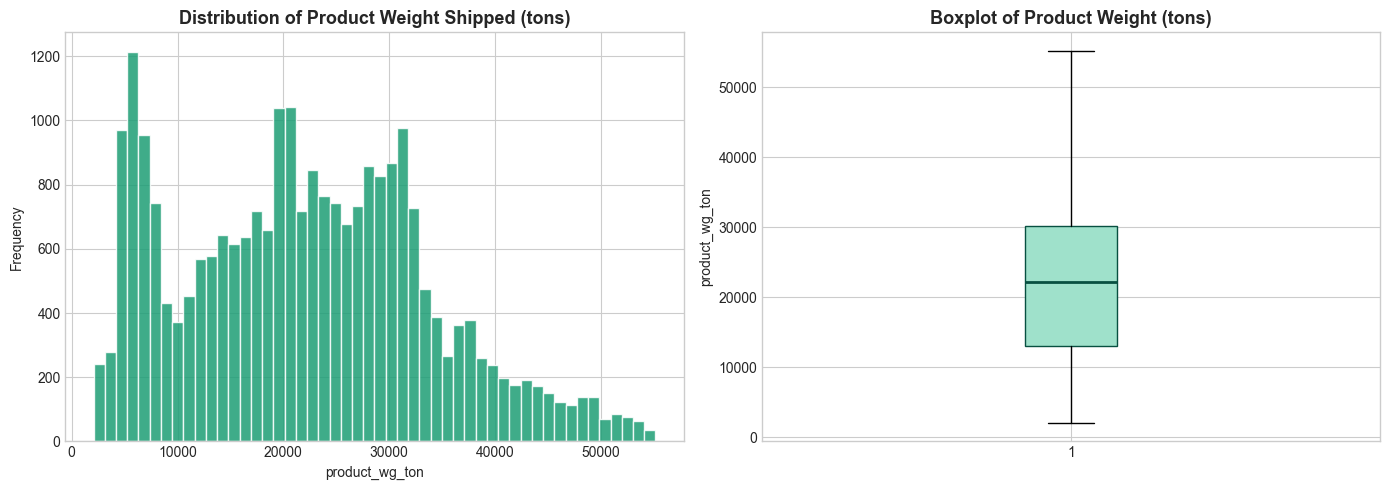

Mean: 22102.6 | Std: 11607.8 | Min: 2065 | Max: 55151


In [10]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['product_wg_ton'], bins=50, color='#1D9E75', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Product Weight Shipped (tons)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('product_wg_ton')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['product_wg_ton'], patch_artist=True,
                boxprops=dict(facecolor='#9FE1CB', color='#085041'),
                medianprops=dict(color='#085041', linewidth=2))
axes[1].set_title('Boxplot of Product Weight (tons)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('product_wg_ton')

plt.tight_layout()
plt.show()
print(f"Mean: {df["product_wg_ton"].mean():.1f} | Std: {df["product_wg_ton"].std():.1f} | Min: {df["product_wg_ton"].min()} | Max: {df["product_wg_ton"].max()}")

=== Demand by Zone ===
       Mean Tons  Median Tons  Warehouse Count
zone                                          
East     22721.5      23081.0              429
North    22199.4      22111.0            10278
South    21933.5      22071.0             6362
West     22079.4      22105.0             7931


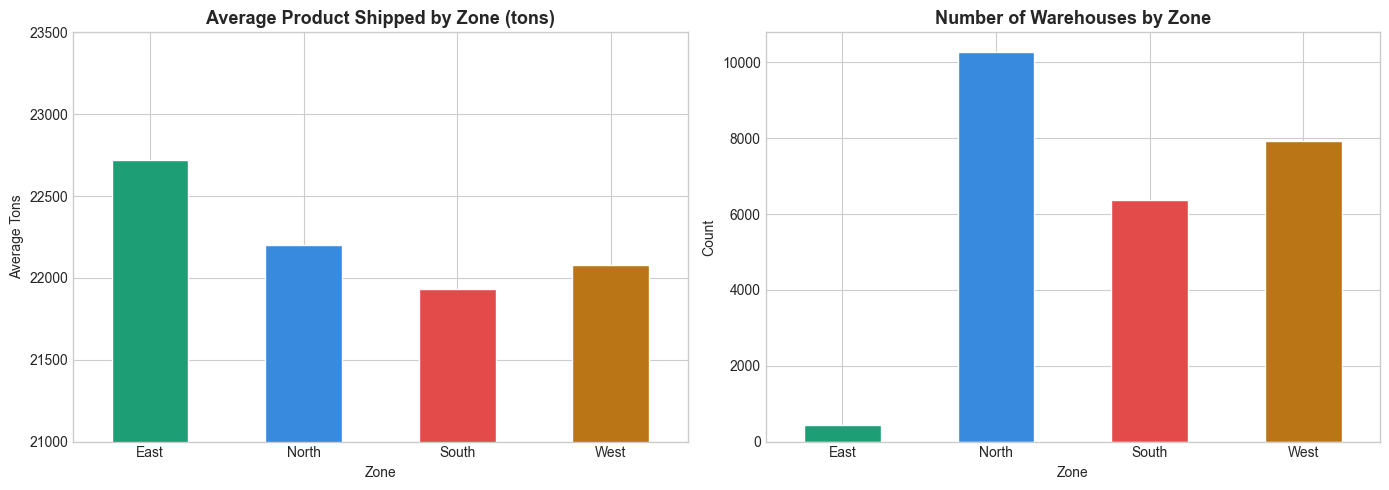

In [11]:
# Demand analysis by Zone
zone_analysis = df.groupby('zone')['product_wg_ton'].agg(['mean', 'median', 'count']).round(1)
zone_analysis.columns = ['Mean Tons', 'Median Tons', 'Warehouse Count']
print("=== Demand by Zone ===")
print(zone_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1D9E75', '#378ADD', '#E24B4A', '#BA7517']
zone_analysis['Mean Tons'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Average Product Shipped by Zone (tons)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('Average Tons')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(21000, 23500)

zone_analysis['Warehouse Count'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Number of Warehouses by Zone', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

=== Demand by Location Type ===
               Mean Tons  Median Tons  Warehouse Count
Location_type                                         
Rural            21844.4      22072.0            22957
Urban            25004.0      25074.0             2043


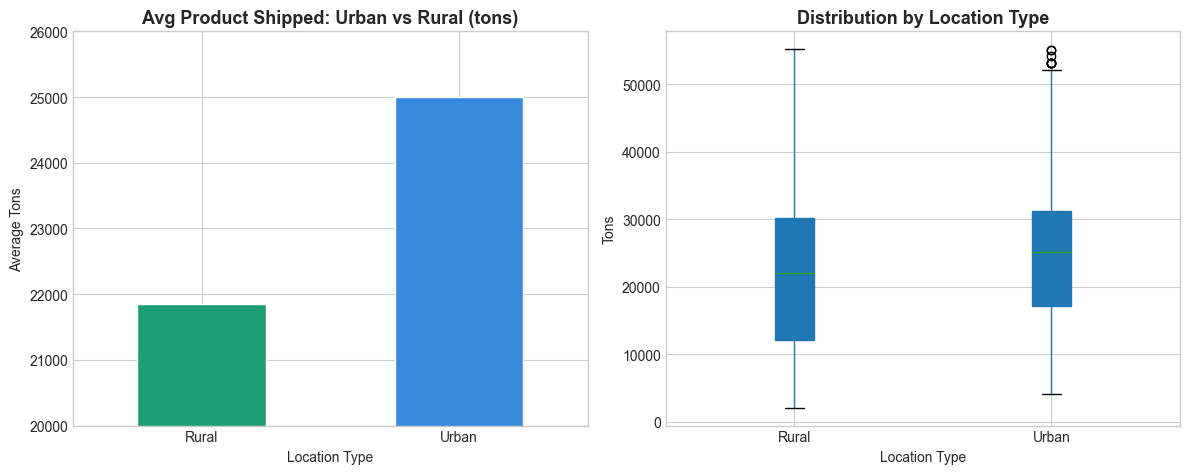

In [12]:
# Urban vs Rural demand
loc_analysis = df.groupby('Location_type')['product_wg_ton'].agg(['mean', 'median', 'count']).round(1)
loc_analysis.columns = ['Mean Tons', 'Median Tons', 'Warehouse Count']
print("=== Demand by Location Type ===")
print(loc_analysis)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

loc_analysis['Mean Tons'].plot(kind='bar', ax=axes[0], color=['#1D9E75','#378ADD'], edgecolor='white')
axes[0].set_title('Avg Product Shipped: Urban vs Rural (tons)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Location Type')
axes[0].set_ylabel('Average Tons')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(20000, 26000)

df.boxplot(column='product_wg_ton', by='Location_type', ax=axes[1],
           patch_artist=True)
axes[1].set_title('Distribution by Location Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Location Type')
axes[1].set_ylabel('Tons')
plt.suptitle('')

plt.tight_layout()
plt.show()

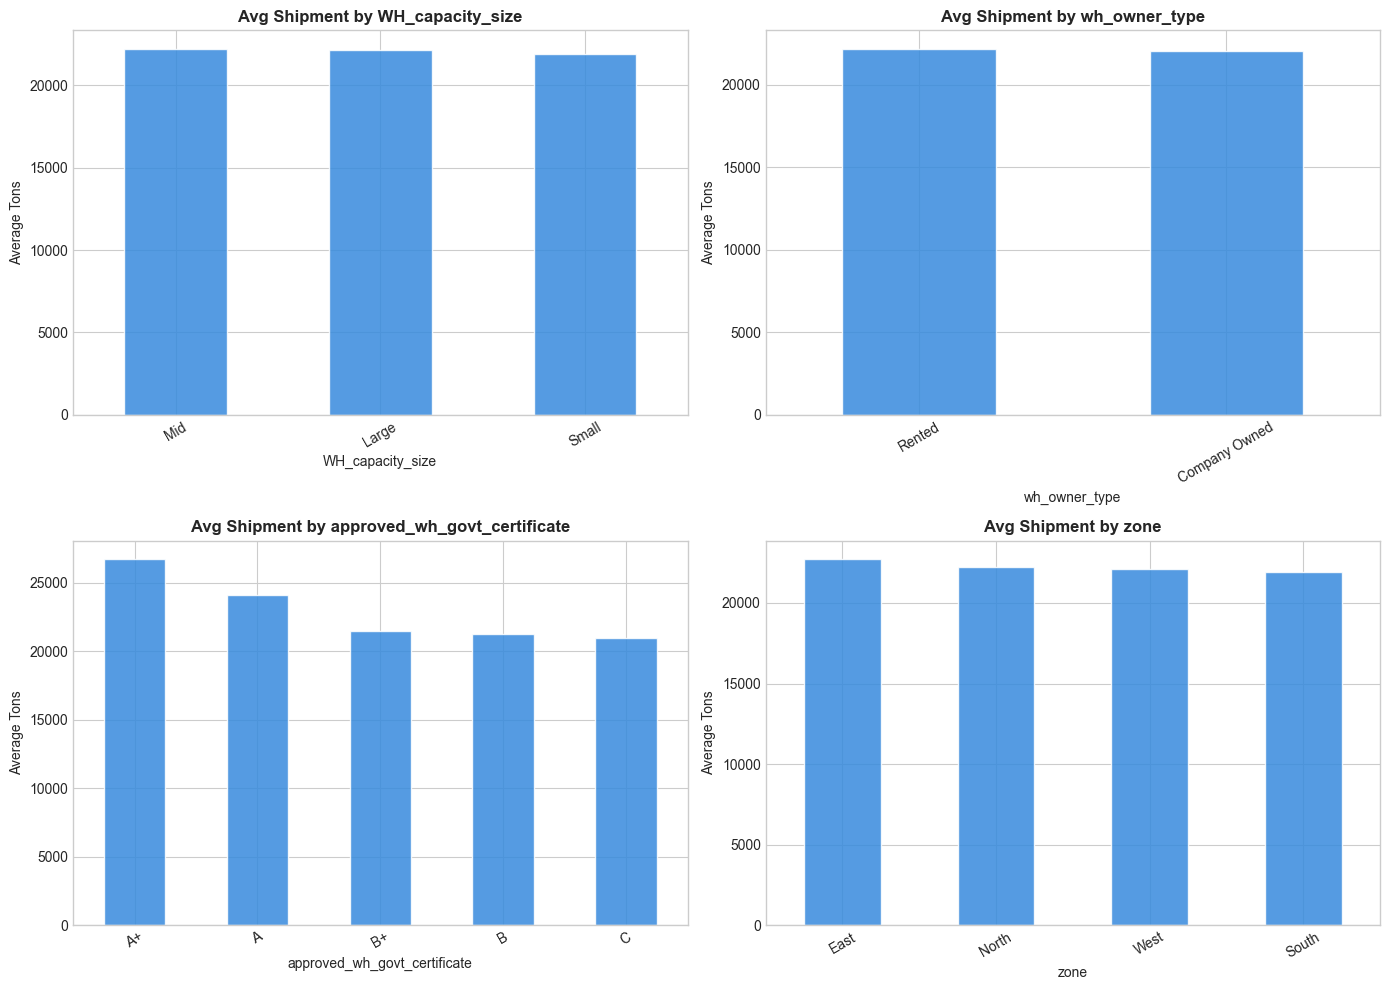

In [13]:
# Categorical feature distributions
cat_cols = ['WH_capacity_size', 'wh_owner_type', 'approved_wh_govt_certificate', 'zone']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    grouped = df.groupby(col)['product_wg_ton'].mean().sort_values(ascending=False)
    grouped.plot(kind='bar', ax=axes[i], color='#378ADD', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Avg Shipment by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Average Tons')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

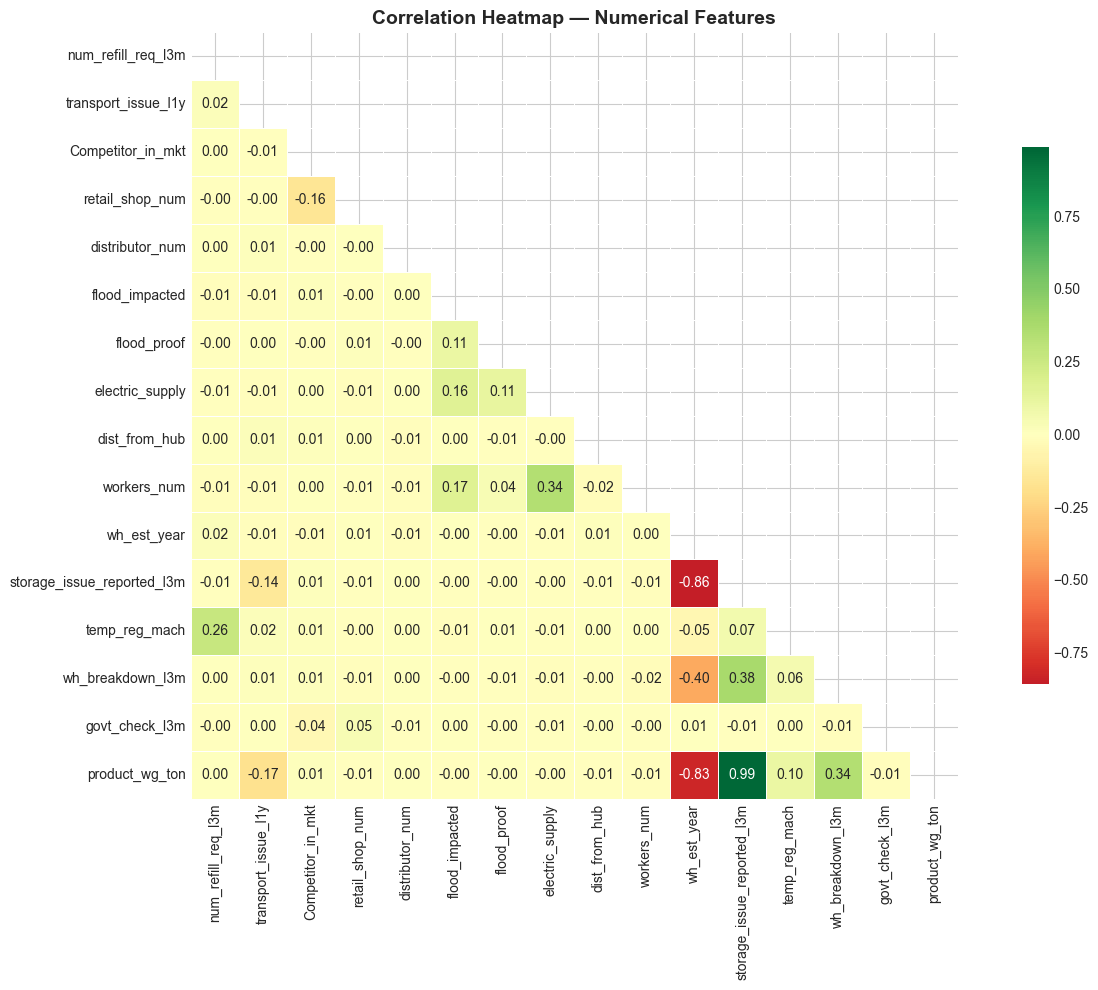

In [14]:
# Correlation heatmap (numerical columns)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

4. Data Preprocessing & Feature Engineering

In [16]:
# Copy dataframe for processing
df_model = df.copy()

# Drop non-predictive ID columns
df_model = df_model.drop(columns=['Ware_house_ID', 'WH_Manager_ID'])

# Feature Engineering: Warehouse Age
df_model['wh_est_year'] = df_model['wh_est_year'].fillna(df_model['wh_est_year'].median())
df_model['wh_age'] = 2026 - df_model['wh_est_year']
df_model = df_model.drop(columns=['wh_est_year'])
print("Created: wh_age feature")

# Impute workers_num with median
df_model['workers_num'] = df_model['workers_num'].fillna(df_model['workers_num'].median())
print("Imputed: workers_num (median)")

# Impute approved_wh_govt_certificate with mode
df_model['approved_wh_govt_certificate'] = df_model['approved_wh_govt_certificate'].fillna(
    df_model['approved_wh_govt_certificate'].mode()[0]
)
print("Imputed: approved_wh_govt_certificate (mode)")

# Ordinal encoding: WH_capacity_size
capacity_map = {'Small': 1, 'Mid': 2, 'Large': 3}
df_model['WH_capacity_size'] = df_model['WH_capacity_size'].map(capacity_map)
print("Encoded: WH_capacity_size (ordinal)")

# Ordinal encoding: approved_wh_govt_certificate
cert_map = {'C': 1, 'B': 2, 'B+': 3, 'A': 4, 'A+': 5}
df_model['approved_wh_govt_certificate'] = df_model['approved_wh_govt_certificate'].map(cert_map)
print("Encoded: approved_wh_govt_certificate (ordinal)")

# Label encode remaining categorical columns
le = LabelEncoder()
for col in ['Location_type', 'zone', 'WH_regional_zone', 'wh_owner_type']:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'Encoded: {col} (label)')

print(f'\nFinal dataset shape: {df_model.shape}')
print(f'Missing values remaining: {df_model.isnull().sum().sum()}')

Created: wh_age feature
Imputed: workers_num (median)
Imputed: approved_wh_govt_certificate (mode)
Encoded: WH_capacity_size (ordinal)
Encoded: approved_wh_govt_certificate (ordinal)
Encoded: Location_type (label)
Encoded: zone (label)
Encoded: WH_regional_zone (label)
Encoded: wh_owner_type (label)

Final dataset shape: (25000, 22)
Missing values remaining: 0


In [17]:
df_model.head()

,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,wh_owner_type,distributor_num,...,electric_supply,dist_from_hub,workers_num,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton,wh_age
0,1,1,3,5,3,1,2,4651,1,24,...,1,91,29.0,13,0,4,5,15,17115,17.0
1,0,3,1,4,0,0,4,6217,0,47,...,1,210,31.0,4,0,4,3,17,5074,17.0
2,0,2,2,1,1,0,4,4306,0,64,...,0,161,37.0,17,0,4,6,22,23137,17.0
3,0,2,1,2,7,4,2,6000,1,50,...,0,103,21.0,17,1,5,3,27,22115,17.0
4,0,3,1,4,3,1,2,4740,0,42,...,1,112,25.0,18,0,1,6,24,24071,17.0


5. Model Building

In [19]:
# Define features and target
X = df_model.drop(columns=['product_wg_ton'])
y = df_model['product_wg_ton']

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")
print(f"Target — Mean: {y.mean():.1f} | Std: {y.std():.1f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Features: 21 | Samples: 25000
Target — Mean: 22102.6 | Std: 11607.8

Train size: 20000 | Test size: 5000


In [20]:
# Helper function to evaluate any model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    print(f'  {name}:')
    print(f'    R²   = {r2:.4f}')
    print(f'    RMSE = {rmse:.1f} tons')
    print(f'    MAE  = {mae:.1f} tons')
    return {'name': name, 'r2': r2, 'rmse': rmse, 'mae': mae, 'model': model, 'pred': pred}

print("=== Model Comparison ===")
results = []
results.append(evaluate_model('Linear Regression',  LinearRegression(),                                               X_train, X_test, y_train, y_test))
results.append(evaluate_model('Ridge Regression',   Ridge(alpha=10),                                                  X_train, X_test, y_train, y_test))
results.append(evaluate_model('Random Forest',      RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1), X_train, X_test, y_train, y_test))
results.append(evaluate_model('Gradient Boosting',  GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42), X_train, X_test, y_train, y_test))

best = max(results, key=lambda x: x['r2'])
print(f"\n Best Model: {best["name"]} (R² = {best["r2"]:.4f})")

=== Model Comparison ===
  Linear Regression:
    R²   = 0.9769
    RMSE = 1757.3 tons
    MAE  = 1308.3 tons
  Ridge Regression:
    R²   = 0.9769
    RMSE = 1757.3 tons
    MAE  = 1308.3 tons
  Random Forest:
    R²   = 0.9942
    RMSE = 878.4 tons
    MAE  = 654.6 tons
  Gradient Boosting:
    R²   = 0.9946
    RMSE = 850.4 tons
    MAE  = 635.0 tons

 Best Model: Gradient Boosting (R² = 0.9946)


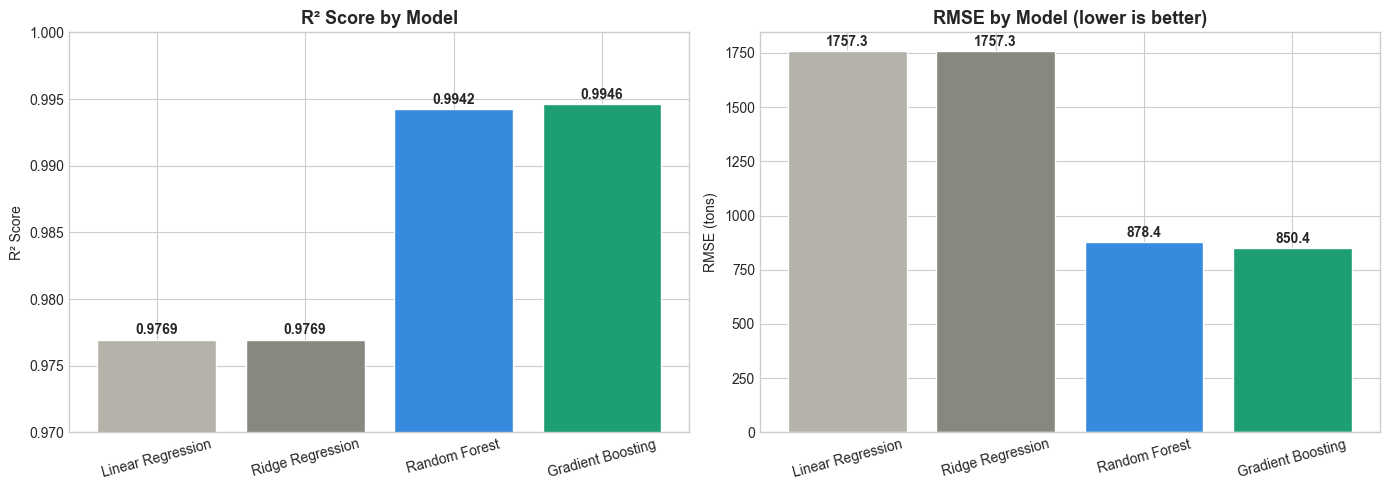

In [21]:
# Model comparison bar chart
model_names = [r['name'] for r in results]
r2_scores   = [r['r2']   for r in results]
rmse_scores = [r['rmse'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#B4B2A9', '#888780', '#378ADD', '#1D9E75']

bars = axes[0].bar(model_names, r2_scores, color=colors, edgecolor='white')
axes[0].set_title('R² Score by Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0.97, 1.0)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(model_names, rmse_scores, color=colors, edgecolor='white')
axes[1].set_title('RMSE by Model (lower is better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE (tons)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

6. Feature Importance Analysis

                     Feature  Importance
  storage_issue_reported_l3m    0.983542
approved_wh_govt_certificate    0.009082
                      wh_age    0.001360
         transport_issue_l1y    0.000751
               temp_reg_mach    0.000746
             retail_shop_num    0.000655
               dist_from_hub    0.000630
             distributor_num    0.000586
                 workers_num    0.000501
            wh_breakdown_l3m    0.000472
              govt_check_l3m    0.000462
          num_refill_req_l3m    0.000316
           Competitor_in_mkt    0.000209
            WH_regional_zone    0.000174
                        zone    0.000136


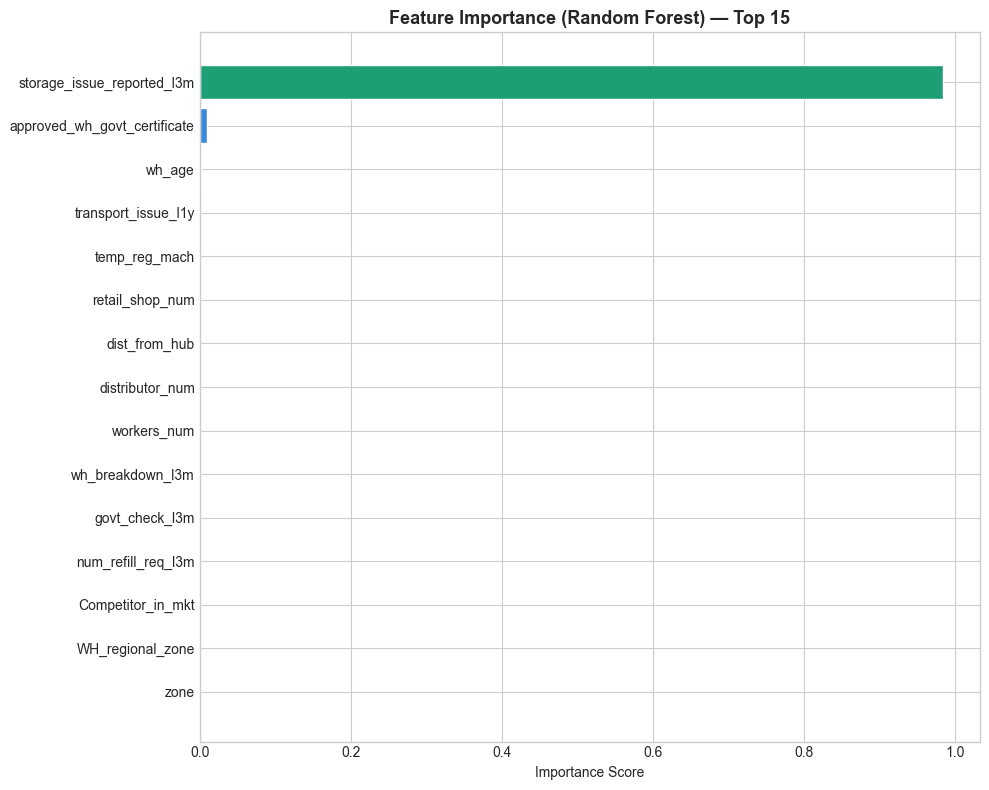

In [23]:
# Feature importance from Random Forest
rf_model = next(r for r in results if r['name'] == 'Random Forest')['model']
importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)
print(feat_imp_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top15 = feat_imp_df.head(15)
colors_fi = ['#1D9E75' if i == 0 else '#378ADD' if i == 1 else '#B4B2A9' for i in range(len(top15))]
ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors_fi[::-1], edgecolor='white')
ax.set_title('Feature Importance (Random Forest) — Top 15', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

7. Best Model — Predictions vs Actual

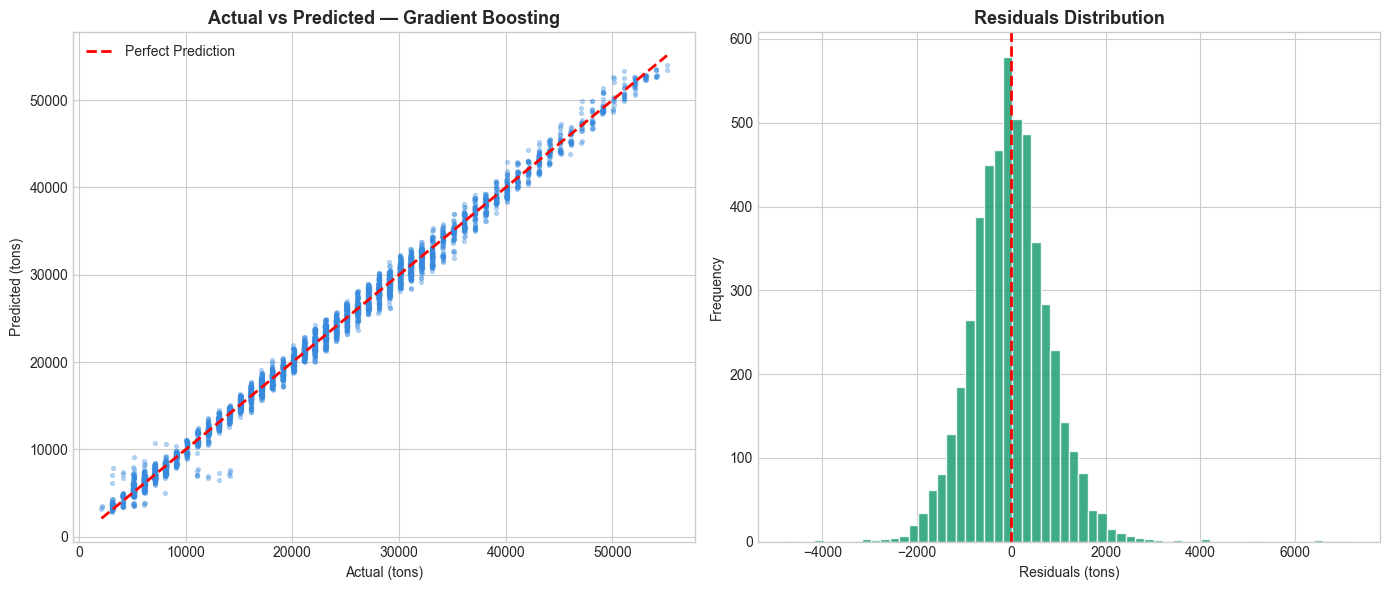

Model: Gradient Boosting
R²   = 0.9946
RMSE = 850.4 tons
MAE  = 635.0 tons


In [25]:
best_model = best['model']
y_pred = best['pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='#378ADD', s=8)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted — {best["name"]}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual (tons)')
axes[0].set_ylabel('Predicted (tons)')
axes[0].legend()

# Residuals distribution
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=60, color='#1D9E75', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residuals (tons)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Model: {best["name"]}")
print(f"R²   = {best["r2"]:.4f}")
print(f"RMSE = {best["rmse"]:.1f} tons")
print(f"MAE  = {best["mae"]:.1f} tons")

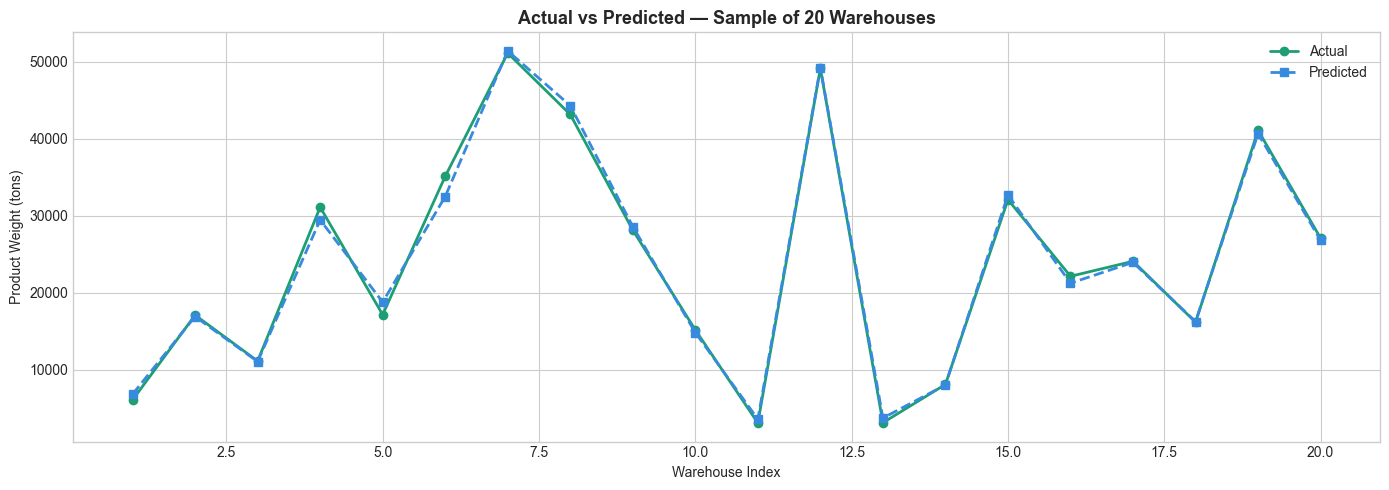

In [26]:
# Sample: First 20 actual vs predicted
sample_actual = y_test.values[:20]
sample_pred   = y_pred[:20]
indices = range(1, 21)

plt.figure(figsize=(14, 5))
plt.plot(indices, sample_actual, 'o-', color='#1D9E75', linewidth=2, label='Actual', markersize=6)
plt.plot(indices, sample_pred,   's--', color='#378ADD', linewidth=2, label='Predicted', markersize=6)
plt.title('Actual vs Predicted — Sample of 20 Warehouses', fontsize=13, fontweight='bold')
plt.xlabel('Warehouse Index')
plt.ylabel('Product Weight (tons)')
plt.legend()
plt.tight_layout()
plt.show()

8. Business Insights & Recommendations

In [28]:
print('=' * 60)
print('           BUSINESS INSIGHTS SUMMARY')
print('=' * 60)

print(f'''
1. BEST MODEL: {best['name']}
   - R² Score : {best['r2']:.4f} (explains {best['r2']*100:.2f}% of variance)
   - RMSE     : {best['rmse']:.1f} tons
   - MAE      : {best['mae']:.1f} tons

2. TOP PREDICTOR: storage_issue_reported_l3m (98.4% importance)
   - Warehouses with storage issues (moisture, pests) receive
     significantly more product to compensate for losses.
   - ACTION: Improve storage quality to reduce over-supply.

3. URBAN vs RURAL DEMAND:
   - Urban : ~25,004 tons avg  (2,043 warehouses)
   - Rural : ~21,844 tons avg  (22,957 warehouses)
   - Urban warehouses ship 14.5% more. Focus ad campaigns on
     urban pockets for max demand uplift.

4. ZONE ANALYSIS (avg tons shipped):
   - East  : 22,722 tons  (only 429 warehouses — potentially underserved)
   - North : 22,199 tons  (largest zone: 10,278 warehouses)
   - West  : 22,079 tons
   - South : 21,934 tons
   - East zone shows high demand but low warehouse count —
     a strong advertising opportunity.

5. GOVT CERTIFICATE & WAREHOUSE AGE:
   - Higher-rated (A+) warehouses tend to receive more product.
   - Warehouse age has a small but measurable impact.
''')
print('=' * 60)

           BUSINESS INSIGHTS SUMMARY

1. BEST MODEL: Gradient Boosting
   - R² Score : 0.9946 (explains 99.46% of variance)
   - RMSE     : 850.4 tons
   - MAE      : 635.0 tons

2. TOP PREDICTOR: storage_issue_reported_l3m (98.4% importance)
   - Warehouses with storage issues (moisture, pests) receive
     significantly more product to compensate for losses.
   - ACTION: Improve storage quality to reduce over-supply.

3. URBAN vs RURAL DEMAND:
   - Urban : ~25,004 tons avg  (2,043 warehouses)
   - Rural : ~21,844 tons avg  (22,957 warehouses)
   - Urban warehouses ship 14.5% more. Focus ad campaigns on
     urban pockets for max demand uplift.

4. ZONE ANALYSIS (avg tons shipped):
   - East  : 22,722 tons  (only 429 warehouses — potentially underserved)
   - North : 22,199 tons  (largest zone: 10,278 warehouses)
   - West  : 22,079 tons
   - South : 21,934 tons
   - East zone shows high demand but low warehouse count —
     a strong advertising opportunity.

5. GOVT CERTIFICATE & WAR